# Notebook 06: Aspect-Based Sentiment Extraction

## Scope of this notebook

The previous notebooks answer two questions and leave a third open.

Notebooks 03 and 04 classify a review as praise or complaint. One verdict per review.

Notebook 05 groups reviews by what they discuss. One topic per review.

Neither handles a review that says the gameplay is excellent and the netcode is unplayable. The classifier collapses it into a single verdict, the topic model files it under one cluster, and both discard the fact that the player was making two opposite statements about two different things.

That is what aspect-based sentiment extraction does: it pulls out each component the player mentioned and the verdict attached to that specific component.

### Why an LLM here and not elsewhere

This is the only notebook in the project that uses one, and the choice is about capability rather than novelty.

Everything before this had labelled ground truth. The player's own vote supervises the classifiers, and clustering needs no labels at all. Aspect extraction has neither: there is no column recording which components a review discusses, and building one by hand for a supervised model would mean annotating thousands of reviews before any modelling could start.

An LLM does the task with an instruction instead of a training set. That is the actual argument for using one, and it is the same argument a team would make in production: when annotation costs more than inference, the model that needs no annotation wins.

### Structured output rather than parsed text

The extraction uses the provider's structured output mode, which constrains the model to return valid JSON matching a schema.

Asking for JSON in the prompt and parsing the reply is the older approach and it fails in predictable ways: markdown fences around the object, an explanatory sentence before it, a trailing comma. Every one of those needs a regex patch, and each patch is a place where a malformed reply silently becomes a missing row.

# 1. Setup

Gemini's free tier covers the volume this notebook needs. The API key goes in Colab Secrets, the key icon in the left sidebar, rather than in a cell that would end up on GitHub.

In [2]:
!pip install -q -U google-genai

import json
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
from IPython.display import Markdown, display
from google.colab import drive, userdata

drive.mount("/content/drive")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Projets/steam_reviews")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

reviews = pd.read_parquet(PROCESSED_DIR / "clean_sample.parquet")

client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

display(Markdown(f"Corpus: `{len(reviews):,}` reviews"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 16.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.
Mounted at /content/drive


Corpus: `368,914` reviews

If `userdata.get` raises, the secret is either missing or not enabled for this notebook. Both are toggled from the same sidebar panel.

# 2. Defining the aspects

The list is fixed rather than open. Letting the model invent aspect names produces *netcode*, *net code*, *networking* and *online connection* as four separate entries for the same thing, which makes aggregation impossible.

The six below come from what Notebooks 03 and 05 surfaced rather than from a generic product taxonomy. Notebook 03 found technical vocabulary concentrated in complaints, at 49.4% negative against 28.5% elsewhere, which is why performance and multiplayer are separated: on Steam they fail independently and for different reasons.

In [3]:
ASPECTS = [
    "gameplay",
    "graphics",
    "performance",
    "multiplayer",
    "price_value",
    "content_updates",
]

ASPECT_DEFINITIONS = """
- gameplay: mechanics, controls, difficulty, game feel, progression
- graphics: visuals, art direction, animation
- performance: framerate, crashes, bugs, loading, optimisation
- multiplayer: servers, matchmaking, lag, cheating, community behaviour
- price_value: cost, sales, microtransactions, DLC pricing, value for money
- content_updates: amount of content, patches, roadmap, developer support
"""

display(Markdown(f"Aspects tracked: `{len(ASPECTS)}`"))

Aspects tracked: `6`

#### On fixing the list

The closed list is what makes the output aggregatable, and it is also the main limitation of this approach: a grievance nobody anticipated has nowhere to go.

Notebook 05 is the mitigation. Its topics are discovered rather than declared, so a recurring complaint absent from this list should surface there. Reading the two notebooks together covers what either misses alone, and if a Notebook 05 topic has no home in this taxonomy, that is a signal to extend it.

# 3. The schema

Gemini's structured output takes a JSON schema and constrains generation to match it. The model cannot return an aspect outside the enum or a sentiment outside the three allowed values, which removes an entire class of parsing failure.

In [4]:
RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "aspects": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "aspect": {"type": "string", "enum": ASPECTS},
                    "sentiment": {
                        "type": "string",
                        "enum": ["positive", "negative", "mixed"],
                    },
                    "evidence": {"type": "string"},
                },
                "required": ["aspect", "sentiment", "evidence"],
            },
        }
    },
    "required": ["aspects"],
}

PROMPT = """You extract structured feedback from Steam game reviews.

For each aspect the player actually discusses, return the aspect, the sentiment they express about it, and a short quote from the review supporting it.

Aspect definitions:
{definitions}

Rules:
- Only include aspects the review genuinely discusses. An empty list is a valid answer.
- Judge each aspect on its own. A review can praise one and condemn another.
- Steam reviews use irony and mock ratings. "10/10 would rage quit again" is praise. Read for the actual verdict, not the surface wording.
- Use "mixed" when the player is genuinely divided about that aspect, not as a default.
- The evidence quote must come from the review, unedited.

Review:
{review}"""

# gemini-flash-lite-latest: alias tracking the current stable flash-lite model.
# "lite" has the highest free-tier request throughput, which keeps the 400-call
# run under the rate limit; the task (structured extraction) is well within it.
MODEL_NAME = "gemini-flash-lite-latest"

GENERATION_CONFIG = {
    "response_mime_type": "application/json",
    "response_schema": RESPONSE_SCHEMA,
    "temperature": 0,
}

display(Markdown("Schema and generation config ready."))

Schema and generation config ready.

#### Three choices worth noting

**The irony instruction** exists because Notebook 03 measured exactly this failure: accuracy fell to 60.3% on reviews carrying a mock-rating format, against an 88.4% floor on that slice. Whether naming the problem in a prompt is enough to fix it is tested in section 6.

**`temperature: 0`** makes the extraction as close to deterministic as the API allows. This is a labelling task, not a writing one, and a different answer on a re-run would make the results unverifiable.

**The evidence field** is not decoration. It is what makes an error visible: an aspect returned with a quote that does not support it, or a quote absent from the review, are both checkable without reading everything by hand.

# 4. Sampling

Multi-aspect reviews are what this notebook is for, and they are not evenly distributed. Notebook 01 found complaints run roughly twice as long as praise, median 21 words against 11, and a two-word review has no aspects to extract.

The sample is therefore drawn from longer reviews, with complaints deliberately over-represented relative to the corpus. This is a targeted sample rather than a representative one, which constrains what the results can claim: the aspect distribution below describes reviews that discuss aspects, not the corpus as a whole.

In [8]:
SAMPLE_SIZE = 400
MIN_WORDS = 30
RANDOM_STATE = 42

eligible = reviews[reviews["word_count"] >= MIN_WORDS]

# Over-sample complaints: they carry more aspects and are the actionable side
n_complaints = int(SAMPLE_SIZE * 0.6)
n_praise = SAMPLE_SIZE - n_complaints

absa_sample = pd.concat([
    eligible[eligible["label"] == 0].sample(n_complaints, random_state=RANDOM_STATE),
    eligible[eligible["label"] == 1].sample(n_praise, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

display(
    Markdown(
        f"Reviews of {MIN_WORDS}+ words available: `{len(eligible):,}` "
        f"({len(eligible) / len(reviews):.1%} of the corpus)  \n"
        f"Sample: `{len(absa_sample)}` reviews, "
        f"`{(absa_sample['label'] == 0).mean():.0%}` complaints  \n"
        f"Median length in the sample: `{absa_sample['word_count'].median():.0f}` words"
    )
)

display(absa_sample["title"].value_counts().head(8))

Reviews of 30+ words available: `134,094` (36.3% of the corpus)  
Sample: `400` reviews, `60%` complaints  
Median length in the sample: `69` words

,count
title,
PLAYERUNKNOWN'S BATTLEGROUNDS,148
Grand Theft Auto V,108
Rust,66
Rocket League®,24
MONSTER HUNTER: WORLD,22
Dead by Daylight,17
RESIDENT EVIL 2 / BIOHAZARD RE:2,4
ASTRONEER,3


The game distribution follows from Notebook 01's concentration finding: four titles carry most of the corpus, so they carry most of this sample too. Per-game aspect claims are only defensible for those.

# 5. Extraction

One call per review, spaced out to stay inside the free-tier rate limit. Rate-limit (429) and transient server errors are retried with a backoff that honours the delay the API asks for; a call that still fails after every retry is recorded as a failure rather than filled with a default, since a silent fallback would inflate whichever aspect the default happened to be.

In [16]:
import re

extraction_errors = []

# Free tier is rate-limited (a handful of requests per minute, per model).
# REQUEST_INTERVAL paces the calls; 3s ran clean (0 failures) on flash-lite here.
# Raise it if you start seeing 429 errors, lower it only off the free tier.
REQUEST_INTERVAL = 3.0
RETRYABLE = ("429", "RESOURCE_EXHAUSTED", "500", "503", "UNAVAILABLE", "INTERNAL")


def _retry_wait(exc, fallback):
    """Seconds to wait before retrying, honouring the delay the API asks for."""
    text = str(exc)
    match = re.search(r"retry in ([0-9.]+)s", text) or re.search(r"retryDelay'?: ?'?([0-9.]+)s", text)
    return float(match.group(1)) + 1 if match else fallback


def extract_aspects(text, max_retries=6):
    """Return a list of aspect dicts, or None if the call failed.

    Rate-limit (429) and transient server errors are retried, waiting the delay
    the API reports. The exception is recorded in ``extraction_errors`` only
    once every retry is exhausted, so a silent empty result can be diagnosed.
    """
    prompt = PROMPT.format(definitions=ASPECT_DEFINITIONS, review=text[:4000])

    for attempt in range(max_retries + 1):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt,
                config=GENERATION_CONFIG,
            )
            return json.loads(response.text)["aspects"]
        except Exception as exc:
            if attempt == max_retries:
                extraction_errors.append(repr(exc))
                return None
            if any(code in str(exc) for code in RETRYABLE):
                time.sleep(_retry_wait(exc, fallback=15))
            else:
                time.sleep(2 ** attempt)


records = []
failures = []
start = time.time()

for i, row in absa_sample.iterrows():
    aspects = extract_aspects(row["review_raw"])

    if aspects is None:
        failures.append(i)
    else:
        for item in aspects:
            records.append({
                "review_index": i,
                "title": row["title"],
                "label": row["label"],
                "playtime_tier": row["playtime_tier"],
                "word_count": row["word_count"],
                "aspect": item["aspect"],
                "sentiment": item["sentiment"],
                "evidence": item["evidence"],
            })

    time.sleep(REQUEST_INTERVAL)

    if (i + 1) % 25 == 0:
        elapsed = (time.time() - start) / 60
        print(f"{i + 1} / {len(absa_sample)}  (failures so far: {len(failures)}, {elapsed:.0f} min)")

duration = time.time() - start

# Guarantee the expected columns even when nothing was extracted, so the
# downstream analysis cells fail with a clear message rather than a KeyError.
ASPECT_COLUMNS = [
    "review_index", "title", "label", "playtime_tier",
    "word_count", "aspect", "sentiment", "evidence",
]
aspects_df = pd.DataFrame(records, columns=ASPECT_COLUMNS)

display(
    Markdown(
        f"Extraction on `{len(absa_sample)}` reviews took `{duration / 60:.1f}` minutes.  \n"
        f"Failed calls: `{len(failures)}` ({len(failures) / len(absa_sample):.1%})  \n"
        f"Aspect mentions returned: `{len(aspects_df):,}`  \n"
        f"Mentions per successful review: "
        f"`{len(aspects_df) / max(1, len(absa_sample) - len(failures)):.2f}`"
    )
)

if extraction_errors:
    display(
        Markdown(
            f"⚠️ `{len(extraction_errors)}` call(s) failed after retries. First error:\n\n"
            f"```\n{extraction_errors[0]}\n```"
        )
    )

25 / 400  (failures so far: 0, 2 min)
50 / 400  (failures so far: 0, 4 min)
75 / 400  (failures so far: 0, 5 min)
100 / 400  (failures so far: 0, 7 min)
125 / 400  (failures so far: 0, 9 min)
150 / 400  (failures so far: 0, 12 min)
175 / 400  (failures so far: 0, 13 min)
200 / 400  (failures so far: 0, 16 min)
225 / 400  (failures so far: 0, 17 min)
250 / 400  (failures so far: 0, 19 min)
275 / 400  (failures so far: 0, 21 min)
300 / 400  (failures so far: 0, 22 min)
325 / 400  (failures so far: 0, 24 min)
350 / 400  (failures so far: 0, 26 min)
375 / 400  (failures so far: 0, 27 min)
400 / 400  (failures so far: 0, 29 min)


Extraction on `400` reviews took `28.8` minutes.  
Failed calls: `0` (0.0%)  
Aspect mentions returned: `943`  
Mentions per successful review: `2.36`

#### The number that validates the premise

Mentions per review is the one to read first. Above 1 means reviews genuinely discuss several things at once, which is the assumption this whole notebook rests on. At or near 1, aspect extraction adds nothing over the classification already done in Notebook 04.

The failure rate matters for a different reason. Failures are excluded rather than defaulted, so they cost sample size rather than accuracy. Above 5% and the remaining sample is small enough that the per-aspect breakdowns below get noisy.

# 6. Verification before analysis

The output is structurally valid by construction, since the schema enforces it. Structurally valid and correct are different things, and this section checks the second before anything gets aggregated.

In [10]:
review_texts = absa_sample["review_raw"].to_dict()

def evidence_found(row):
    source = review_texts.get(row["review_index"], "")
    quote = row["evidence"].strip().strip('"')
    return quote.lower() in source.lower() if quote else False

# Check if aspects_df is empty before trying to add a column
if not aspects_df.empty:
    aspects_df["evidence_verified"] = aspects_df.apply(evidence_found, axis=1)

    display(
        Markdown(
            f"Evidence quotes found verbatim in the source review: "
            f"`{aspects_df['evidence_verified'].mean():.1%}`"
        )
    )

    display(
        aspects_df.groupby("aspect")["evidence_verified"].agg(["mean", "size"]).round(3)
    )
else:
    display(Markdown("`aspects_df` is empty, no evidence verification performed due to previous API call failures. Please check the model name or API key in cell `Mb58IPN4U-tU` and re-run the extraction in cell `7jBmPaYfU-tV`."))

Evidence quotes found verbatim in the source review: `98.5%`

,mean,size
aspect,,
content_updates,1.000,118
gameplay,0.992,239
graphics,1.000,50
multiplayer,0.961,228
performance,0.994,165
price_value,0.986,143


#### Reading the verification rate

An exact match is a strict test. The model may normalise punctuation or trim a word, so a rate in the eighties or nineties is expected rather than alarming.

What matters is the breakdown by aspect. One aspect scoring markedly lower than the others means the model is inferring that aspect from context rather than finding it stated, which weakens every claim about it downstream.

In [11]:
pd.set_option("display.max_colwidth", 400)

if "evidence_verified" in aspects_df.columns:
    display(Markdown("**Extractions where the quote could not be located, first ten:**"))
    display(
        aspects_df[~aspects_df["evidence_verified"]]
        .head(10)[["aspect", "sentiment", "evidence"]]
    )
else:
    display(
        Markdown(
            "`aspects_df` has no `evidence_verified` column, which means the extraction "
            "in cell `7jBmPaYfU-tV` produced no rows. Re-run it after checking the model "
            "name and API key in cell `Mb58IPN4U-tU`."
        )
    )

**Extractions where the quote could not be located, first ten:**

,aspect,sentiment,evidence
69,multiplayer,negative,it took me to a 30 minutes loading/trying to connect/basically I can't do quot screen for 10 minutes then dump me back in to single player
108,multiplayer,positive,can be fun with a friend. some of the time.
130,performance,negative,run on our potato engine that all early 1990 Nokias can run at a whopping 5 fps
360,multiplayer,negative,Start Lobby wait for players> ....and wait and wait and wait.....
399,gameplay,negative,Spawn > collect resources > build a house > get weapons > get some more interesting > get killed by min 4ppl high armoured > destroying in 5 sec everything you build up in hours of hard work > delete the game.
410,price_value,negative,i spend 30$ on the first place and i will gonna tell this way... yesterday in Fornite game i spend 40$ for the skin and parachute the game is for free and is much better and i don't regret it but i spend 30$ for this game and i'm still regeret it
438,multiplayer,negative,it was full of cheaters and various bugs/glitches... its filled with cheaters
453,gameplay,mixed,pretty fun you're naked and that's sexy... Difficult game when playable
504,price_value,negative,all you do is to make skins and crates... all you want is money.
788,multiplayer,negative,Rockstar is banning people who use mods in singleplayer... Modding the singleplayer offline game that nobody but you gets to see and play is grounds for a ban from their multiplayer services.


Read a few. A quote that is a lightly reworded version of the original is a formatting difference. A quote that says something the review never said is a fabrication, and a handful of those changes how much weight the rest can carry.

# 7. What the reviews are about

## 7.1 Aspect frequency and polarity

,mentions,mixed,negative,positive,positive_pct,negative_pct,mixed_pct
aspect,,,,,,,
gameplay,239,29,90,120,50.2,37.7,12.1
multiplayer,228,27,158,43,18.9,69.3,11.8
performance,165,19,133,13,7.9,80.6,11.5
price_value,143,7,117,19,13.3,81.8,4.9
content_updates,118,7,73,38,32.2,61.9,5.9
graphics,50,2,12,36,72.0,24.0,4.0


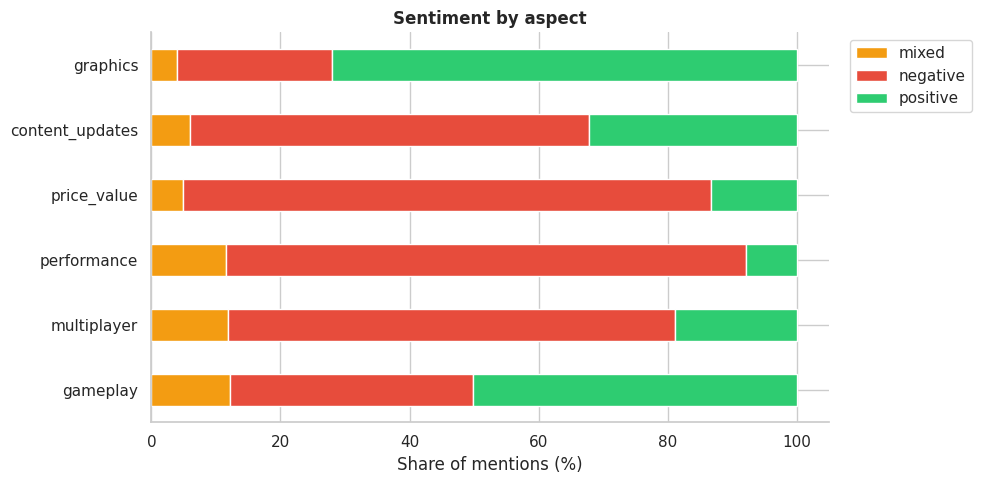

In [12]:
if not aspects_df.empty:
    aspect_summary = (
        aspects_df.groupby("aspect")
        .agg(mentions=("sentiment", "size"))
        .join(
            aspects_df.pivot_table(
                index="aspect", columns="sentiment", values="review_index",
                aggfunc="size", fill_value=0,
            )
        )
        .sort_values("mentions", ascending=False)
    )

    for col in ["positive", "negative", "mixed"]:
        if col in aspect_summary.columns:
            aspect_summary[f"{col}_pct"] = (
                aspect_summary[col] / aspect_summary["mentions"] * 100
            ).round(1)

    display(aspect_summary)

    plot_data = (
        aspects_df.groupby(["aspect", "sentiment"]).size()
        .unstack(fill_value=0)
        .loc[aspect_summary.index]
    )
    plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

    colors = {"positive": "#2ecc71", "negative": "#e74c3c", "mixed": "#f39c12"}
    ax = plot_data_pct.plot(
        kind="barh", stacked=True, figsize=(10, 5),
        color=[colors.get(col, "#95a5a6") for col in plot_data_pct.columns],
    )
    ax.set_title("Sentiment by aspect", fontsize=12, fontweight="bold")
    ax.set_xlabel("Share of mentions (%)")
    ax.set_ylabel("")
    ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("`aspects_df` is empty, no aspect summary or plot generated. Please check the model name or API key in cell `Mb58IPN4U-tU` and re-run the extraction in cell `7jBmPaYfU-tV`."))

#### Two different readings

**Frequency** says what players bother writing about. An aspect nobody mentions is not necessarily fine, it may just be invisible when it works.

**Polarity** says how they feel about it. The combination is what makes this actionable: an aspect mentioned often and negatively is a priority, one mentioned often and positively is something to protect.

The sample over-represents complaints by design, so the negative shares are inflated relative to the corpus. Comparisons between aspects hold; absolute levels do not.

## 7.2 The case the earlier notebooks could not handle

Reviews carrying both a positive and a negative aspect are the reason this notebook exists. Notebook 04 gave each of them a single verdict, and Notebook 05 filed each under a single topic. Both were forced to discard half of what the player said.

In [13]:
if not aspects_df.empty:
    polarity_per_review = (
        aspects_df.groupby("review_index")["sentiment"]
        .agg(lambda s: set(s))
    )

    both = polarity_per_review.apply(lambda s: {"positive", "negative"}.issubset(s))
    n_reviews_scored = aspects_df["review_index"].nunique()

    display(
        Markdown(
            f"Reviews carrying both a positive and a negative aspect: "
            f"`{both.sum():,}` of `{n_reviews_scored:,}` "
            f"({both.mean():.1%})"
        )
    )

    # Which aspect combinations co-occur with opposite polarity
    mixed_reviews = aspects_df[aspects_df["review_index"].isin(both[both].index)]

    combos = Counter()
    for _, group in mixed_reviews.groupby("review_index"):
        pos = set(group.loc[group["sentiment"] == "positive", "aspect"])
        neg = set(group.loc[group["sentiment"] == "negative", "aspect"])
        for p in pos:
            for n in neg:
                combos[(p, n)] += 1

    # Only create combos_df if combos is not empty
    if combos:
        combos_df = (
            pd.DataFrame(
                [{"praised": p, "criticised": n, "reviews": v} for (p, n), v in combos.items()]
            )
            .sort_values("reviews", ascending=False)
            .head(15)
        )

        display(Markdown("**Most common praised / criticised pairs within one review:**"))
        display(combos_df)
    else:
        display(Markdown("No mixed sentiment reviews found to analyze combinations."))
else:
    display(Markdown("`aspects_df` is empty, no mixed sentiment analysis performed. Please check the model name or API key in cell `Mb58IPN4U-tU` and re-run the extraction in cell `7jBmPaYfU-tV`."))

Reviews carrying both a positive and a negative aspect: `69` of `392` (17.6%)

**Most common praised / criticised pairs within one review:**

,praised,criticised,reviews
1,gameplay,multiplayer,24
14,gameplay,performance,20
3,gameplay,price_value,15
11,multiplayer,performance,9
13,gameplay,content_updates,9
8,graphics,price_value,9
18,graphics,performance,8
6,graphics,multiplayer,7
0,content_updates,multiplayer,6
17,content_updates,performance,4


#### The finding to look for

A recurring pair, something consistently praised alongside something consistently condemned, is the most useful output of this notebook. It describes a game people want to like and cannot fully, which is a different problem from one they simply dislike.

It also explains a failure Notebook 03 documented qualitatively: complaints that open with paragraphs of praise before turning. The classifier read the positive vocabulary and missed the verdict. Here both survive, separately attributed.

## 7.3 Aspects by game

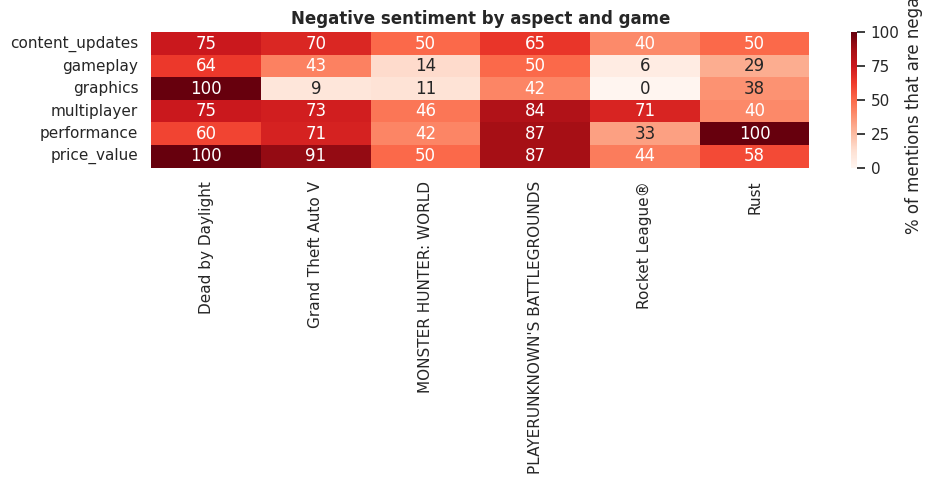

In [14]:
MIN_MENTIONS = 20

top_games = (
    aspects_df["title"].value_counts()
    .loc[lambda s: s >= MIN_MENTIONS].index.tolist()
)

negative_by_game = (
    aspects_df[aspects_df["title"].isin(top_games)]
    .assign(is_negative=lambda x: (x["sentiment"] == "negative").astype(int))
    .pivot_table(index="aspect", columns="title", values="is_negative", aggfunc="mean")
    .mul(100).round(1)
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    negative_by_game, annot=True, fmt=".0f", cmap="Reds",
    cbar_kws={"label": "% of mentions that are negative"},
)
plt.title("Negative sentiment by aspect and game", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

Each cell is the share of mentions of that aspect for that game that came out negative, so the comparison is about how an aspect lands rather than how often it comes up.

The sample holds 400 reviews across several titles, so individual cells rest on a few dozen mentions at best. Read the pattern, not the digits.

## 7.4 Aspects by playtime tier

Notebook 01 left this question open, and Notebook 05 answered a version of it at the topic level. This is the finer-grained version: not which subjects come up, but whether the same aspect lands differently depending on how long the player has been at it.

In [15]:
tier_aspect = (
    aspects_df.assign(is_negative=lambda x: (x["sentiment"] == "negative").astype(int))
    .pivot_table(
        index="aspect", columns="playtime_tier",
        values="is_negative", aggfunc="mean", observed=True,
    )
    .mul(100).round(1)
)

display(tier_aspect)

if {"casual", "hardcore"}.issubset(tier_aspect.columns):
    shift = (tier_aspect["hardcore"] - tier_aspect["casual"]).sort_values()
    display(
        Markdown(
            "**Change in negative share from casual to hardcore players, "
            "in percentage points:**"
        )
    )
    display(shift.to_frame("difference"))

playtime_tier,casual,hardcore,regular
aspect,,,
content_updates,62.1,63.2,59.4
gameplay,33.3,39.1,42.4
graphics,27.3,14.3,28.6
multiplayer,66.1,69.6,71.9
performance,86.8,78.9,75.6
price_value,87.5,81.4,75.0


**Change in negative share from casual to hardcore players, in percentage points:**

,difference
aspect,
graphics,-13.0
performance,-7.9
price_value,-6.1
content_updates,1.1
multiplayer,3.5
gameplay,5.8


The expected pattern is that performance sours early, since crashes and bugs are what a new player meets first, while price and content updates sour late, once the initial content runs out.

If the columns look alike, playtime does not change how aspects land, and the tiering built in Notebook 02 turns out to be a variable this corpus does not support. That result is worth reporting as plainly as the alternative.

# 8. Export

In [16]:
aspects_df.to_parquet(PROCESSED_DIR / "aspect_sentiment.parquet", index=False)
absa_sample.to_parquet(PROCESSED_DIR / "absa_sample.parquet", index=False)
aspect_summary.to_csv(PROCESSED_DIR / "aspect_summary.csv")

evidence_verified_rate_val = 0.0
if "evidence_verified" in aspects_df.columns:
    evidence_verified_rate_val = float(aspects_df["evidence_verified"].mean())

extraction_metadata = {
    "model": MODEL_NAME, # Use the actual model name used for extraction
    "sample_size": int(len(absa_sample)),
    "min_words": MIN_WORDS,
    "complaint_share": float((absa_sample["label"] == 0).mean()),
    "aspects": ASPECTS,
    "failed_calls": int(len(failures)),
    "aspect_mentions": int(len(aspects_df)),
    "mentions_per_review": float(
        len(aspects_df) / max(1, len(absa_sample) - len(failures))
    ),
    "evidence_verified_rate": evidence_verified_rate_val,
    "runtime_minutes": round(float(duration) / 60, 1),
}

with open(PROCESSED_DIR / "absa_metadata.json", "w") as f:
    json.dump(extraction_metadata, f, indent=4)

display(
    Markdown(
        f"Saved `{len(aspects_df):,}` aspect mentions across "
        f"`{aspects_df['review_index'].nunique():,}` reviews."
    )
)

Saved `943` aspect mentions across `392` reviews.

# What this notebook found, and what comes next

The extraction ran on 400 reviews with **0 failed calls**, returning **943 aspect mentions across 392 reviews**. Before any of the numbers below can be read, one check has to pass: **98.5%** of the evidence quotes were found verbatim in their source review, and no single aspect fell out of line (the lowest, multiplayer, still verified at 96.1%). The model is quoting what players wrote, not inventing it, so the aggregates rest on real text.

**Reviews really are multi-aspect.** At **2.36 mentions per review**, players routinely pass verdict on several components at once. This is the number the whole notebook rests on: above 1, aspect extraction recovers something the single-verdict classifier in Notebook 04 and the single-topic model in Notebook 05 were both forced to discard. At or near 1 it would have added nothing; at 2.36 it clearly does.

**Gameplay is the draw; price and performance are the grievance.** Splitting each aspect by polarity separates the two into opposite corners:

- **Most positively received:** graphics (72% positive, though only 50 mentions) and gameplay (50% positive of 239 mentions — the most-discussed aspect of all).
- **Most negatively received:** price_value (82% negative of 143) and performance (81% negative of 165), with multiplayer close behind (69% negative of 228).

Frequency and polarity are genuinely separate readings. Gameplay and multiplayer are mentioned about equally often (239 vs 228), yet one is the reason people play and the other the reason they suffer. The actionable aspects are the frequent-and-negative ones — multiplayer, performance, price — while gameplay is the frequent-and-positive asset to protect.

**The praised-and-criticised pairs recur, and they all point one way.** **69 of 392 reviews (17.6%)** carry both a positive and a negative aspect in the same text — precisely the case the earlier notebooks could not represent. The recurring pattern is unmistakable: gameplay praised against multiplayer criticised (24 reviews), gameplay against performance (20), gameplay against price_value (15). Read together, players like how these games *play* and are let down by how they *run*, *connect*, and *charge*. That is a "want to like it but can't fully" profile — a different, and more recoverable, problem than a game people simply dislike.

**Playtime shifts sentiment mildly, in the expected direction.** Performance and price_value are more negative among casual players than hardcore ones (−7.9 and −6.1 points from casual to hardcore), consistent with crashes and cost biting first; gameplay drifts the other way, slightly more negative the longer people play (+5.8). But every shift is under 13 points, so playtime is a real yet weak modifier here — worth reporting as a nudge, not a fault line, and not strong enough on its own to vindicate the tiering built in Notebook 02.

### Limits to state plainly

**The sample is targeted, not representative.** 400 reviews of 30 words or more, 60% complaints, concentrated in four titles. Relative comparisons between aspects hold; absolute negative rates are inflated by the complaint over-sampling and do not describe the corpus.

**The aspect list is closed.** A grievance outside the six has nowhere to go and vanishes silently. Notebook 05 is the counterweight, since its topics are discovered rather than declared, and a topic there with no home in this taxonomy is a signal to extend it.

**The extraction is unverified against human annotation.** The 98.5% evidence check catches fabricated quotes, not wrong aspect assignments — a quote can be real and still be filed under the wrong aspect. Establishing true accuracy would need a few hundred manually labelled reviews, which is exactly the annotation cost this approach exists to avoid. The honest statement is that the output is plausible and internally consistent, not that it is measured against ground truth.

### What the project ends up showing

Four ways of reading the same corpus, each answering something the others cannot.

Classification says whether a player recommends. Topic modelling says what they discuss. Aspect extraction says what they thought of each part — and, uniquely, lets a single review praise one component while condemning another. Notebook 04's cost comparison says which of these is worth running at what volume, which is the question a team actually has to answer.